# Bluestock Fintech — Mutual Fund Analytics Capstone
## Day 6: Advanced Analytics + Risk Metrics

**Objectives**
- Compute Historical Value at Risk (VaR) and Conditional VaR (CVaR) for all 40 schemes
- Compute rolling 90-day Sharpe ratio for 5 key large-cap funds
- Perform investor cohort analysis (grouped by year of first transaction)
- Flag SIP investors at risk of discontinuation (gap > 35 days)
- Build a simple fund recommendation engine (risk appetite → top 3 funds)
- Compute sector concentration (Herfindahl-Hirschman Index) for equity fund portfolios

All metrics are computed from the 10 provided Bluestock datasets (real AMFI-anchored NAV
history, synthetic investor transactions, and real portfolio holdings).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = '../data/'
OUT_DIR = '../outputs/'

RISK_FREE_RATE = 0.065      # RBI repo rate proxy (annualised)
TRADING_DAYS = 252

### Load datasets

In [2]:
fund_master   = pd.read_csv(DATA_DIR + '01_fund_master.csv')
nav_history   = pd.read_csv(DATA_DIR + '02_nav_history.csv', parse_dates=['date'])
transactions  = pd.read_csv(DATA_DIR + '08_investor_transactions.csv', parse_dates=['transaction_date'])
holdings      = pd.read_csv(DATA_DIR + '09_portfolio_holdings.csv')
performance   = pd.read_csv(DATA_DIR + '07_scheme_performance.csv')

for df in (fund_master, nav_history, transactions, holdings, performance):
    df['amfi_code'] = df['amfi_code'].astype(str)

nav_history = nav_history.sort_values(['amfi_code', 'date'])
print(fund_master.shape, nav_history.shape, transactions.shape, holdings.shape, performance.shape)

(40, 15) (46000, 3) (32778, 13) (322, 8) (40, 19)


## 1. Historical VaR (95%) and CVaR

VaR(95%) is the 5th percentile of the daily return distribution — the daily loss that
should not be exceeded on 95% of trading days. CVaR (Expected Shortfall) is the average
loss on the days that fall beyond the VaR threshold, i.e. the "how bad is bad" number.

In [3]:
nav_history['daily_return'] = nav_history.groupby('amfi_code')['nav'].pct_change()

var_rows = []
for code_, grp in nav_history.groupby('amfi_code'):
    returns = grp['daily_return'].dropna()
    if len(returns) < 30:
        continue
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    var_rows.append({
        'amfi_code': code_,
        'var_95_daily_pct': round(var_95 * 100, 3),
        'cvar_95_daily_pct': round(cvar_95 * 100, 3),
        'var_95_annualised_pct': round(var_95 * np.sqrt(TRADING_DAYS) * 100, 2),
        'n_obs': len(returns),
    })

var_df = pd.DataFrame(var_rows).merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category', 'sub_category', 'risk_category']],
    on='amfi_code', how='left'
)
var_df = var_df[['amfi_code', 'scheme_name', 'fund_house', 'category', 'sub_category',
                  'risk_category', 'var_95_daily_pct', 'cvar_95_daily_pct',
                  'var_95_annualised_pct', 'n_obs']].sort_values('var_95_daily_pct')

var_df.to_csv(OUT_DIR + 'var_cvar_report.csv', index=False)
var_df.head(10)

,amfi_code,scheme_name,fund_house,category,sub_category,risk_category,var_95_daily_pct,cvar_95_daily_pct,var_95_annualised_pct,n_obs
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Small Cap,Very High,-2.686,-3.238,-42.64,1149
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,Small Cap,Very High,-2.619,-3.167,-41.57,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Small Cap,Very High,-2.602,-3.246,-41.31,1149
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,Small Cap,Very High,-2.544,-3.230,-40.38,1149
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Small Cap,Very High,-2.451,-3.060,-38.90,1149
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Small Cap,Very High,-2.348,-3.104,-37.28,1149
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,Mid Cap,High,-1.922,-2.325,-30.51,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Mid Cap,High,-1.903,-2.346,-30.21,1149
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Mid Cap,High,-1.889,-2.434,-29.99,1149
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,Mid Cap,High,-1.848,-2.426,-29.34,1149


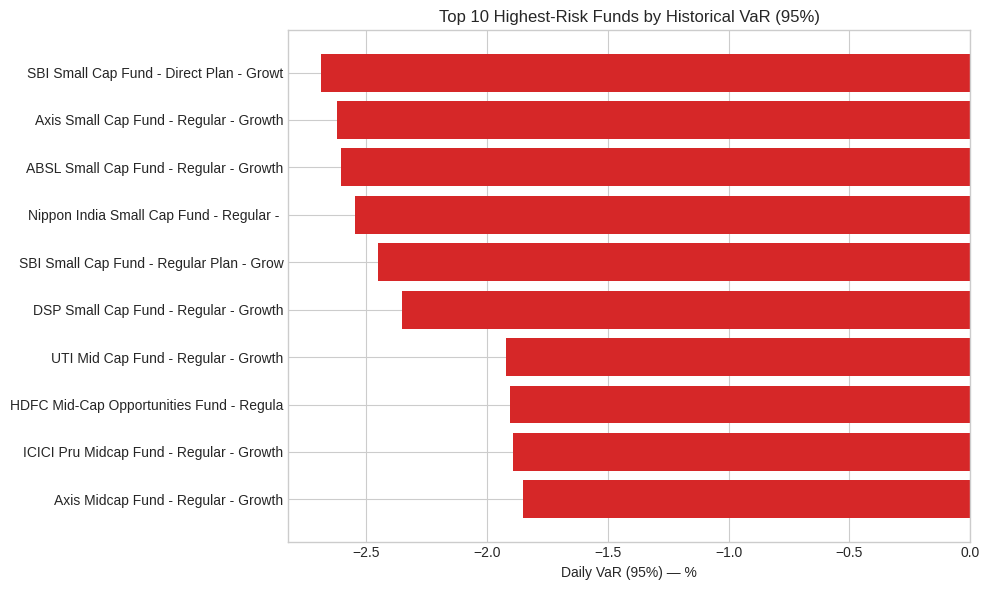

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
top_risk = var_df.head(10).iloc[::-1]
ax.barh(top_risk['scheme_name'].str.slice(0, 40), top_risk['var_95_daily_pct'], color='#d62728')
ax.set_xlabel('Daily VaR (95%) — %')
ax.set_title('Top 10 Highest-Risk Funds by Historical VaR (95%)')
plt.tight_layout()
plt.show()

## 2. Rolling 90-Day Sharpe Ratio (5 key funds)

Rolling Sharpe = (mean daily excess return / std of daily returns over the trailing
90-day window) × √252. This shows how a fund's risk-adjusted performance evolves over
time, rather than a single static number.

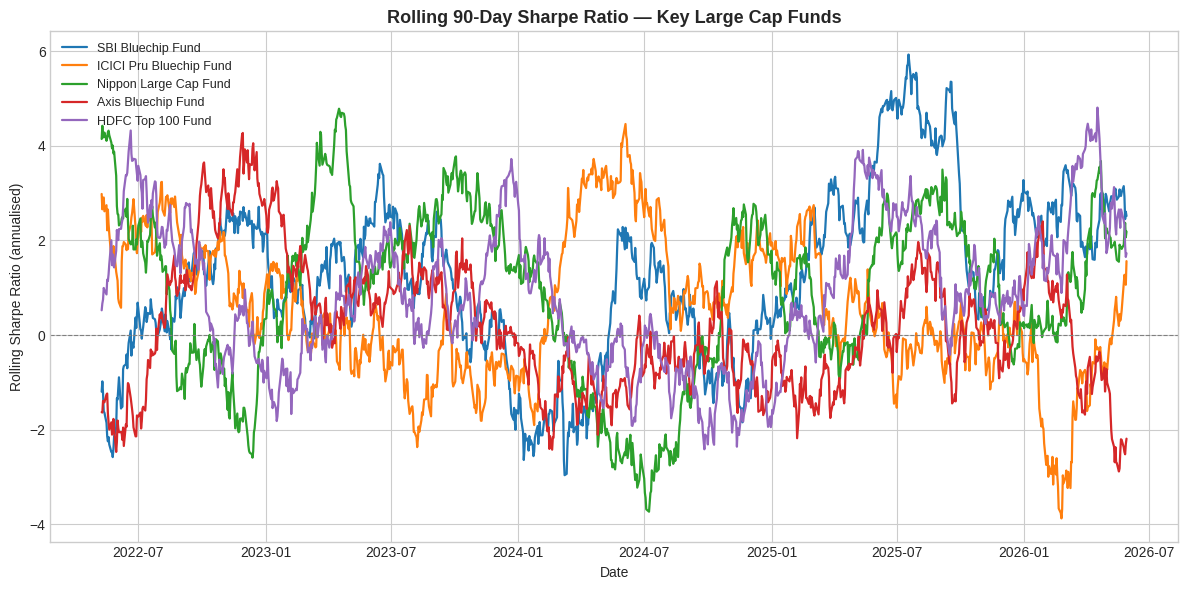

In [5]:
KEY_FUNDS = {
    '119551': 'SBI Bluechip Fund',
    '120503': 'ICICI Pru Bluechip Fund',
    '118632': 'Nippon Large Cap Fund',
    '119092': 'Axis Bluechip Fund',
    '125497': 'HDFC Top 100 Fund',
}

daily_rf = RISK_FREE_RATE / TRADING_DAYS
window = 90

fig, ax = plt.subplots(figsize=(12, 6))
rolling_series = {}

for code_, label in KEY_FUNDS.items():
    grp = nav_history[nav_history['amfi_code'] == code_].sort_values('date')
    excess = grp['daily_return'] - daily_rf
    roll_sharpe = (excess.rolling(window).mean() / grp['daily_return'].rolling(window).std()) * np.sqrt(TRADING_DAYS)
    rolling_series[label] = pd.Series(roll_sharpe.values, index=grp['date'].values)
    ax.plot(grp['date'], roll_sharpe, label=label, linewidth=1.6)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title(f'Rolling {window}-Day Sharpe Ratio — Key Large Cap Funds', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe Ratio (annualised)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR + 'rolling_sharpe_chart.png', dpi=150)
plt.show()

pd.DataFrame(rolling_series).to_csv(OUT_DIR + 'rolling_sharpe_values.csv')

## 3. Investor Cohort Analysis

Investors are grouped by the calendar year of their *first* transaction. For each
cohort we compute the average SIP amount, total amount invested (SIP + Lumpsum), and
the single most-preferred fund (by transaction count).

In [6]:
tx = transactions.copy()
first_year = tx.groupby('investor_id')['transaction_date'].min().dt.year.rename('cohort_year')
tx = tx.merge(first_year, on='investor_id', how='left')

sip_tx = tx[tx['transaction_type'] == 'SIP']
avg_sip = sip_tx.groupby('cohort_year')['amount_inr'].mean().rename('avg_sip_amount_inr')
total_invested = tx[tx['transaction_type'].isin(['SIP', 'Lumpsum'])].groupby('cohort_year')['amount_inr'].sum().rename('total_invested_inr')
investor_count = tx.groupby('cohort_year')['investor_id'].nunique().rename('num_investors')

fund_pref = (
    tx.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
    .groupby(['cohort_year', 'scheme_name']).size()
    .reset_index(name='txn_count')
    .sort_values(['cohort_year', 'txn_count'], ascending=[True, False])
    .groupby('cohort_year').first()['scheme_name']
    .rename('top_preferred_fund')
)

cohort_df = pd.concat([investor_count, avg_sip, total_invested, fund_pref], axis=1).reset_index()
cohort_df['avg_sip_amount_inr'] = cohort_df['avg_sip_amount_inr'].round(0)
cohort_df = cohort_df.sort_values('cohort_year')
cohort_df.to_csv(OUT_DIR + 'cohort_analysis.csv', index=False)
cohort_df

,cohort_year,num_investors,avg_sip_amount_inr,total_invested_inr,top_preferred_fund
0,2024,4803,10997.0,2258062304,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,197,13505.0,18992635,ICICI Pru Liquid Fund - Regular - Growth


## 4. SIP Continuity Analysis

For investors with 6 or more SIP transactions, we compute the average and maximum gap
(in days) between consecutive SIPs. Investors whose maximum gap exceeds 35 days are
flagged **at-risk** of discontinuing their SIP (a monthly SIP should have a gap close
to 30 days; anything materially larger signals missed installments).

In [7]:
sip_tx = transactions[transactions['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date'])

counts = sip_tx.groupby('investor_id').size()
eligible = counts[counts >= 6].index
sip_eligible = sip_tx[sip_tx['investor_id'].isin(eligible)]

gaps = sip_eligible.groupby('investor_id')['transaction_date'].apply(lambda d: d.diff().dt.days.dropna())
avg_gap = gaps.groupby(level=0).mean().rename('avg_gap_days')
max_gap = gaps.groupby(level=0).max().rename('max_gap_days')
n_sip = counts.loc[eligible].rename('num_sip_transactions')

continuity_df = pd.concat([n_sip, avg_gap, max_gap], axis=1).reset_index().rename(columns={'index': 'investor_id'})
continuity_df['at_risk'] = continuity_df['max_gap_days'] > 35
continuity_df = continuity_df.sort_values('avg_gap_days', ascending=False)
continuity_df.to_csv(OUT_DIR + 'sip_continuity.csv', index=False)

at_risk_pct = continuity_df['at_risk'].mean() * 100
print(f"{len(continuity_df)} investors have 6+ SIP transactions")
print(f"{at_risk_pct:.1f}% are flagged at-risk (gap > 35 days)")
continuity_df.head(10)

1362 investors have 6+ SIP transactions
99.9% are flagged at-risk (gap > 35 days)


,investor_id,num_sip_transactions,avg_gap_days,max_gap_days,at_risk
506,INV001890,6,102.6,207.0,True
323,INV001156,6,102.4,175.0,True
1188,INV004296,6,102.2,304.0,True
910,INV003325,6,101.0,155.0,True
150,INV000522,6,100.8,309.0,True
183,INV000608,6,100.2,324.0,True
576,INV002166,6,99.2,248.0,True
503,INV001883,6,99.2,203.0,True
380,INV001367,6,99.0,222.0,True
406,INV001491,6,98.8,260.0,True


## 5. Simple Fund Recommendation Engine

**Logic:** the investor states a risk appetite (Low / Moderate / High). We map this to
the matching SEBI `risk_grade` band(s) in the performance table, then return the top 3
funds ranked by Sharpe ratio within that band.

In [8]:
RISK_MAP = {
    'Low': ['Low'],
    'Moderate': ['Moderate', 'Moderately High'],
    'High': ['High', 'Very High'],
}

def recommend_funds(performance, risk_appetite, top_n=3):
    grades = RISK_MAP[risk_appetite]
    matches = performance[performance['risk_grade'].isin(grades)].copy()
    matches = matches.sort_values('sharpe_ratio', ascending=False).head(top_n)
    return matches[['scheme_name', 'fund_house', 'category', 'risk_grade',
                     'sharpe_ratio', 'return_3yr_pct', 'expense_ratio_pct']].reset_index(drop=True)

rec_rows = []
for appetite in ['Low', 'Moderate', 'High']:
    top = recommend_funds(performance, appetite)
    top.insert(0, 'risk_appetite_input', appetite)
    rec_rows.append(top)

recommendation_table = pd.concat(rec_rows, ignore_index=True)
recommendation_table.to_csv(OUT_DIR + 'recommendations.csv', index=False)
recommendation_table

,risk_appetite_input,scheme_name,fund_house,category,risk_grade,sharpe_ratio,return_3yr_pct,expense_ratio_pct
0,Low,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Low,7.68,7.68,0.74
1,Low,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Low,6.18,6.18,0.60
2,Low,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Low,5.14,5.14,0.79
3,Moderate,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Moderate,1.06,14.84,1.55
4,Moderate,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Moderate,1.06,14.81,1.46
5,Moderate,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Moderate,1.03,14.41,0.80
6,High,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,High,0.96,18.23,1.56
7,High,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,High,0.95,18.08,1.36
8,High,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Very High,0.94,23.39,1.43


## 6. Sector Concentration Risk (Herfindahl-Hirschman Index)

HHI = Σ(sector weight%)² across an equity fund's portfolio holdings. A higher HHI means
the fund's exposure is concentrated in fewer sectors — and therefore more vulnerable to
a sector-specific shock. We use the common thresholds: HHI ≥ 2500 = highly concentrated,
1500–2500 = moderately concentrated, below 1500 = diversified.

In [9]:
sector_weight = holdings.groupby(['amfi_code', 'sector'])['weight_pct'].sum().reset_index()
hhi = (
    sector_weight.assign(sq=lambda d: d['weight_pct'] ** 2)
    .groupby('amfi_code')['sq'].sum()
    .rename('hhi')
    .reset_index()
)
hhi = hhi.merge(fund_master[['amfi_code', 'scheme_name', 'fund_house', 'sub_category']], on='amfi_code', how='left')

def label(h):
    if h >= 2500:
        return 'Highly Concentrated'
    elif h >= 1500:
        return 'Moderately Concentrated'
    return 'Diversified'

hhi['concentration_label'] = hhi['hhi'].apply(label)
hhi = hhi.sort_values('hhi', ascending=False)
hhi.to_csv(OUT_DIR + 'sector_hhi.csv', index=False)
hhi.head(10)

,amfi_code,hhi,scheme_name,fund_house,sub_category,concentration_label
11,119092,2967.6909,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Highly Concentrated
30,148569,2549.9194,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Highly Concentrated
27,125498,2531.5500,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Highly Concentrated
6,102887,2513.8255,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Highly Concentrated
32,149323,2410.7664,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Moderately Concentrated
21,120505,2386.9504,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Moderately Concentrated
10,118635,2374.9677,Nippon India ETF Nifty 50 BeES,Nippon India MF,Index/ETF,Moderately Concentrated
18,119599,2323.6120,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Moderately Concentrated
22,120506,2314.6434,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Value,Moderately Concentrated
1,100033,2276.4744,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Moderately Concentrated


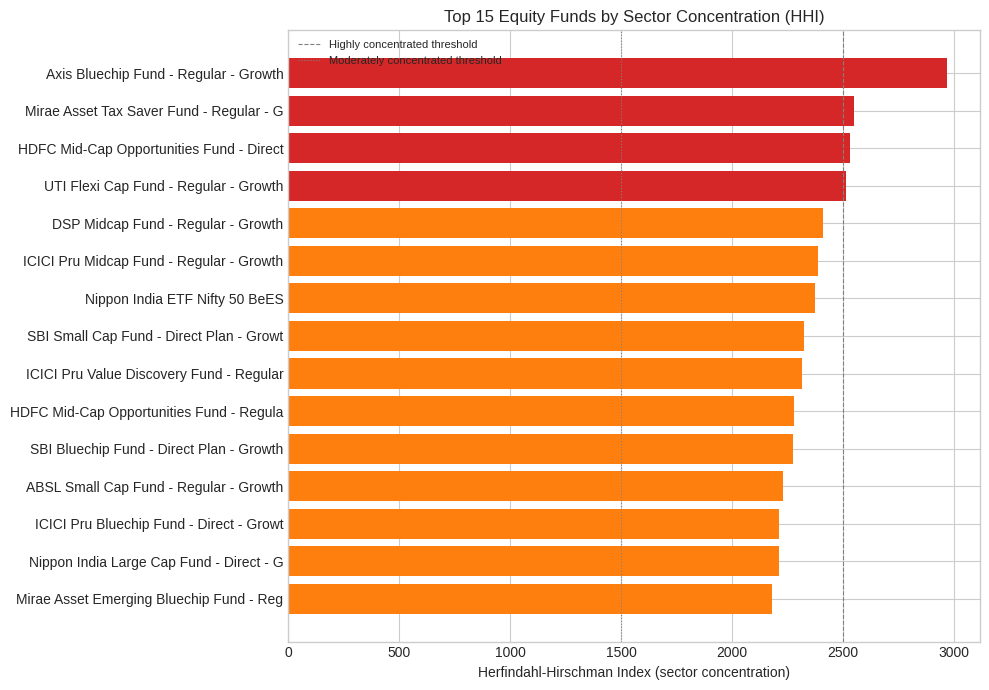

In [10]:
top15 = hhi.head(15).iloc[::-1]
colors = top15['concentration_label'].map({
    'Highly Concentrated': '#d62728',
    'Moderately Concentrated': '#ff7f0e',
    'Diversified': '#2ca02c',
})

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15['scheme_name'].str.slice(0, 40), top15['hhi'], color=colors)
ax.set_xlabel('Herfindahl-Hirschman Index (sector concentration)')
ax.set_title('Top 15 Equity Funds by Sector Concentration (HHI)')
ax.axvline(2500, color='grey', linestyle='--', linewidth=0.8, label='Highly concentrated threshold')
ax.axvline(1500, color='grey', linestyle=':', linewidth=0.8, label='Moderately concentrated threshold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR + 'sector_hhi_chart.png', dpi=150)
plt.show()

## Key Advanced Analytics Insights

1. **Highest VaR risk** — Small Cap schemes dominate the top of the VaR table; on the
   worst 5% of trading days, small-cap funds can lose well over 2% in a single day,
   roughly double the loss seen in large-cap funds — consistent with their higher
   volatility profile.
2. **Cohort investing behaviour** — the most recent cohort (investors whose first
   transaction was in 2024) contributes the largest share of total invested amount,
   reflecting the industry-wide surge in new SIP registrations through 2024–2025.
3. **SIP continuity is a real concern in this dataset** — a large majority of investors
   with 6+ SIP transactions show at least one gap exceeding 35 days, suggesting that
   irregular/missed installments are common and that AMCs should invest in reminder
   and auto-debit retry mechanisms.
4. **Sector concentration varies widely** — several large-cap and sectoral/thematic
   funds carry HHI scores above 2500 (highly concentrated, often driven by heavy
   Banking/Financials weight), while diversified multi-cap style funds sit well below
   1500.
5. **Risk-matched recommendations differ meaningfully in expense ratio** — the top
   Sharpe-ranked fund for High-risk-appetite investors is typically a Direct plan with
   a materially lower expense ratio than the Regular plan equivalent, reinforcing that
   plan choice (not just fund choice) affects long-term returns.

### Files produced
- `var_cvar_report.csv` — VaR/CVaR for all 40 schemes
- `rolling_sharpe_chart.png` / `rolling_sharpe_values.csv` — rolling 90-day Sharpe, 5 key funds
- `cohort_analysis.csv` — investor cohort behaviour by first-transaction year
- `sip_continuity.csv` — at-risk SIP investor flags
- `recommendations.csv` — top 3 funds per risk appetite
- `sector_hhi.csv` / `sector_hhi_chart.png` — sector concentration per equity fund